# Traditional and Digital Financial Literacy in Italy

**Research question:** Should traditional and digital financial literacy be reported together or separately?

This notebook uses the 2023 IACOFI survey from Banca d'Italia. The first version keeps the analysis simple: reconstruct the official scores, check them against published results, and identify people whose traditional and digital skills do not match.

## 1. Setup

We only use common Python libraries. All paths are relative to the project folder.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# 数据文件和输出文件夹
DATA_FILE = Path("data/raw/stata/Database_ENG.dta")
FIGURE_DIR = Path("output/figures")
TABLE_DIR = Path("output/tables")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# 统一图片风格
# Unify the style of the figures
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

## 2. Load the data

In [2]:
# convert_categoricals=False：保留问卷中的原始数字编码，方便按照OECD规则计分
# convert_categoricals=False：store the original encoding in questionaire
# to count under the rules of OECD
df = pd.read_stata(DATA_FILE, convert_categoricals=False).copy()

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Survey weight available: {'wght' in df.columns}")

Rows: 4,862
Columns: 219
Survey weight available: True


In [3]:
"""Calculate the weighted average"""
def weighted_mean(values, weights):
    return np.average(values, weights=weights)

weights = df["wght"]

## 3. Reconstruct traditional financial literacy

The official traditional score has three parts: knowledge (0–7), behaviour (0–9), and attitudes (0–4).

In [4]:
# ---------- traditional financial literacy：7 scores ----------
# 每道题答对得1分，答错、不知道或拒绝回答得0分
# 1 point for  each correct answer
# 0 point for wrong answer or ignorance, or not answering

knowledge_items = [
    df["qk3"].isin([3, 4]),              # inflation and purchaing power
    df["qk4"].eq(0),                     # Borrowing interest
    df["qk5"].eq(102),                   # One year simple interest
    df["qk5"].eq(102) & df["qk6"].eq(1), # Five-year compound interest; (previous question correct).
    df["qk7_1"].eq(1),                          # Returns and Risks
    df["qk7_2"].eq(1),                          # inflation definition
    df["qk7_3"].eq(1),                          # risk diversification
]

df["traditional_knowledge"] = sum(item.astype(int) for item in knowledge_items)

In [5]:
# ---------- traditional financial behavior：9 scores ----------

# 1) Responsible for managing money and using at least two budgeting methods.
budget_columns = [f"qf2_{i}" for i in range(1, 7)]
responsible_for_money = df["qf1"].isin([1, 2]) | df["qf1_a"].eq(1)
keeps_budget = df[budget_columns].eq(1).sum(axis=1).ge(2)

budget_score = (responsible_for_money & keeps_budget).astype(int)

# 2) Have used at least one active savings method in the past 12 months
saving_columns = [
    "qf3_1", "qf3_2", "qf3_3", "qf3_5",
    "qf3_6", "qf3_7", "qf3_8", "qf3_81"
]

saving_score = df[saving_columns].eq(1).any(axis=1).astype(int)

# 3) loans, credit card overdrafts, or defaulting on bills when income is insufficient
borrowing_columns = [
    "qf12_3_1", "qf12_3_2", "qf12_3_3", "qf12_3_7",
    "qf12_4_1", "qf12_4_2", "qf12_5_1", "qf12_5_3",
    "qf12_6_1", "qf12_6_2"
]
no_borrowing_score = (~df[borrowing_columns].eq(1).any(axis=1)).astype(int)

# comparison or independent information usage while selecting financial products (max 2 points)

independent_info = df[["qp7_1", "qp7_2", "qp7_3"]].eq(1).any(axis=1)
other_info = df[["qp7_4", "qp7_5", "qp7_6", "qp7_7"]].eq(1).any(axis=1)
compared_products = df["qp5"].isin([1, 4])

product_choice_score = pd.Series(
    np.select(
        [independent_info, compared_products | other_info],
        [2, 1],
        default=0,
    ),
    index=df.index,
)

# 5–8) four daily financial behaviours, 1 points each question
watch_score = df["qs1_5"].isin([1, 2]).astype(int) # close attention to financial situation
goal_score = df["qs1_8"].isin([1, 2]).astype(int) # Set long-term goals
afford_score = df["qs2_3"].isin([1, 2]).astype(int) # assessing affordability before purchasing
bill_score = df["qs2_5"].isin([1, 2]).astype(int) # pay bills on time

df["traditional_behaviour"] = (
    budget_score + saving_score + no_borrowing_score + product_choice_score
    + watch_score + goal_score + afford_score + bill_score
)

In [6]:
# ---------- traditional financial attitudes：0 to 4 points ----------
# 三道题原始答案为1到5；无效回答按OECD规则替换为中间值3
#The original answers to the three questions were 1 to 5;
# invalid answers were replaced with the median value of 3 according to OECD rules.
attitude_columns = ["qs1_1", "qs1_3", "qs3_11"]
attitude_answers = df[attitude_columns].where(
    df[attitude_columns].isin([1, 2, 3, 4, 5]),
    3,
)
df["traditional_attitude"] = attitude_answers.mean(axis=1) - 1

# 传统金融素养总分：0到20分
# traditional financial attitudes total points: 0 to 20
df["traditional_total"] = (
    df["traditional_knowledge"]
    + df["traditional_behaviour"]
    + df["traditional_attitude"]
)

## 4. Reconstruct digital financial literacy

The digital score has three parts: knowledge (0–3), behaviour (0–4), and attitudes (0–3). Banca d'Italia reports this score for respondents with internet access, so people without internet access are kept as a separate digital-exclusion group rather than incorrectly assigning them a score of zero.

In [7]:
# ---------- digital financial literacy：3 points ----------
df["digital_knowledge"] = (
    df["qk7_4"].eq(0).astype(int)    # Digital contracts do not require paper signatures to be valid.
    + df["qk7_5"].eq(1).astype(int)  # Publicly available data may be used for business profiling.
    + df["qk7_6"].eq(0).astype(int)  # Crypto assets are not fiat currency
)

# ---------- digital financial behaviours：4 points ----------
df["digital_behaviour"] = (
    df["qs2_6"].isin([4, 5]).astype(int)     # no sharing passwords or PIN with friends
    + df["qs2_7"].isin([1, 2]).astype(int)   # Check whether the service provider is regulated
    + df["qs2_8"].isin([4, 5]).astype(int)   # Do not publicly share personal financial information
    + df["qs3_13"].isin([1, 2]).astype(int)  # Change password regularly
)

# ---------- Digital finance attitude：3 points ----------
df["digital_attitude"] = (
    df["qs4_1"].isin([4, 5]).astype(int)    # Knowing that shopping over public Wi-Fi is unsafe
    + df["qs4_2"].isin([1, 2]).astype(int)  # Pay attention to website security
    + df["qs4_3"].isin([4, 5]).astype(int)  # Pay attention to transaction terms and conditions
)

# 数字金融素养总分：0到10分
# Digital finance attitude total points: 0 to 10
df["digital_total"] = (
    df["digital_knowledge"]
    + df["digital_behaviour"]
    + df["digital_attitude"]
)

# 央行数字金融结果只针对能够上网的受访者
# The results of the central bank's digital finance survey
# only apply to respondents who have internet access.
has_internet = df["qd14"].eq(1)
print(f"Respondents with internet access: {has_internet.sum():,}")

Respondents with internet access: 4,427


## 5. Validate the reconstructed scores

Before analysing the research question, we compare our weighted means with the official Banca d'Italia results. Matching the published values is an important data-quality check.

In [8]:
# 传统分数使用全部受访者；数字分数使用能够上网的受访者
# Traditional scores use all respondents;
# digital scores use respondents with internet access.
validation = pd.DataFrame(
    {
        "Our weighted mean": [
            weighted_mean(df["traditional_knowledge"], weights),
            weighted_mean(df["traditional_behaviour"], weights),
            weighted_mean(df["traditional_attitude"], weights),
            weighted_mean(df["traditional_total"], weights),
            weighted_mean(df.loc[has_internet, "digital_knowledge"], weights[has_internet]),
            weighted_mean(df.loc[has_internet, "digital_behaviour"], weights[has_internet]),
            weighted_mean(df.loc[has_internet, "digital_attitude"], weights[has_internet]),
            weighted_mean(df.loc[has_internet, "digital_total"], weights[has_internet]),
        ],
        "Official published mean": [3.7, 4.7, 2.3, 10.7, 1.3, 2.1, 1.2, 4.6],
    },
    index=[
        "Traditional knowledge (0-7)",
        "Traditional behaviour (0-9)",
        "Traditional attitude (0-4)",
        "Traditional total (0-20)",
        "Digital knowledge (0-3)",
        "Digital behaviour (0-4)",
        "Digital attitude (0-3)",
        "Digital total (0-10)",
    ],
)

validation.round(3)

,Our weighted mean,Official published mean
Traditional knowledge (0-7),3.694,3.700
Traditional behaviour (0-9),4.676,4.700
Traditional attitude (0-4),2.308,2.300
Traditional total (0-20),10.679,10.700
Digital knowledge (0-3),1.280,1.300
Digital behaviour (0-4),2.086,2.100
Digital attitude (0-3),1.236,1.200
Digital total (0-10),4.602,4.600


In [9]:
# 保存核对表，之后可以直接用于报告
# Save the checklist to be used directly in reports later.
validation.round(3).to_csv(TABLE_DIR / "score_validation.csv")

## 6. First comparison of traditional and digital literacy

The two scores use different ranges, so we convert both to percentages. The comparison sample contains only respondents with internet access.

In [10]:
# 只保留能够上网的人，因为他们才有可比较的数字金融分数
# Only those with internet access are included,
# because only they have comparable digital financial scores.
analysis = df.loc[has_internet].copy()

# 统一转换为0到100，方便比较；这一步不代表把两个分数合并
# Convert all values to the range 0 to 100 for easier comparison;
# this step does not mean merging the two fractions.
analysis["traditional_pct"] = analysis["traditional_total"] / 20 * 100
analysis["digital_pct"] = analysis["digital_total"] / 10 * 100

# Spearman相关适合比较两组有序分数，不要求线性关系
# Spearman correlation is suitable for comparing two sets of ordered scores,
# and a linear relationship is not required.
correlation, p_value = spearmanr(
    analysis["traditional_pct"],
    analysis["digital_pct"],
)

print(f"Spearman correlation: {correlation:.3f}")
print(f"p-value: {p_value:.3g}")

Spearman correlation: 0.443
p-value: 4.83e-212


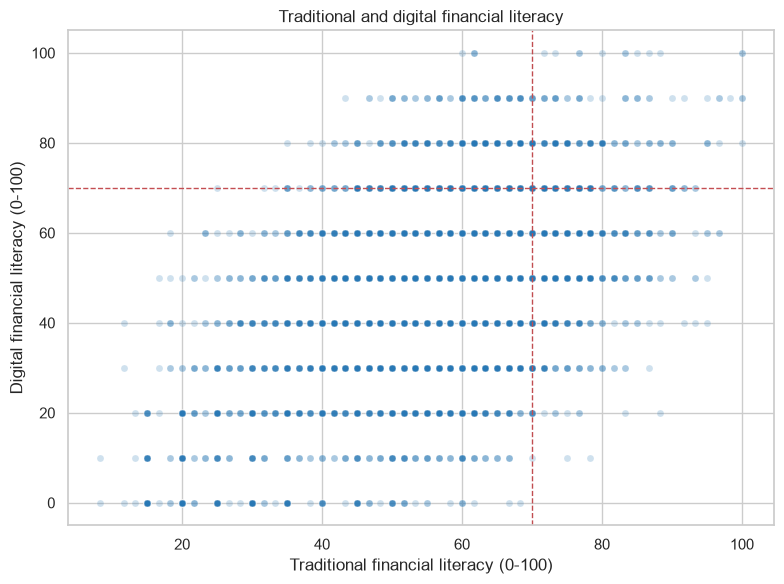

In [11]:
# 每个点代表一名受访者；红色虚线是70%的最低目标线
# Each dot represents a respondent;
# the red dashed line is the minimum target line of 70%.
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=analysis,
    x="traditional_pct",
    y="digital_pct",
    alpha=0.22,
    s=25,
    color="#2878B5",
)
plt.axvline(70, color="#C14D51", linestyle="--", linewidth=1)
plt.axhline(70, color="#C44E52", linestyle="--", linewidth=1)
plt.xlabel("Traditional financial literacy (0-100)")
plt.ylabel("Digital financial literacy (0-100)")
plt.title("Traditional and digital financial literacy")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "traditional_vs_digital.png", dpi=300)
plt.show()

## 7. Four literacy profiles

Using the OECD minimum target of 70%, respondents are divided into four easy-to-interpret groups. The two mixed groups are especially important because they show information that would be hidden by one combined score.

In [12]:
# 是否达到传统和数字金融素养的70%最低目标
# whether achieved the minimum target of 70%
# in both traditional and digital financial literacy
traditional_ok = analysis["traditional_pct"].ge(70)
digital_ok = analysis["digital_pct"].ge(70)

analysis["literacy_profile"] = np.select(
    [
        traditional_ok & digital_ok,
        traditional_ok & ~digital_ok,
        ~traditional_ok & digital_ok,
    ],
    [
        "Both meet target",
        "Traditional only",
        "Digital only",
    ],
    default="Neither meets target",
)

profile_order = [
    "Both meet target",
    "Traditional only",
    "Digital only",
    "Neither meets target",
]

# 使用调查权重计算每一类在意大利成年人中的比例
# Calculate the proportion of each category
# among Italian adults using survey weights.
profile_share = (
    analysis.groupby("literacy_profile", observed=True)["wght"]
    .sum()
    .div(analysis["wght"].sum())
    .mul(100)
    .reindex(profile_order)
    .rename("Weighted percent")
)

profile_share.round(2).to_frame()

,Weighted percent
literacy_profile,
Both meet target,5.840
Traditional only,11.700
Digital only,14.370
Neither meets target,68.090


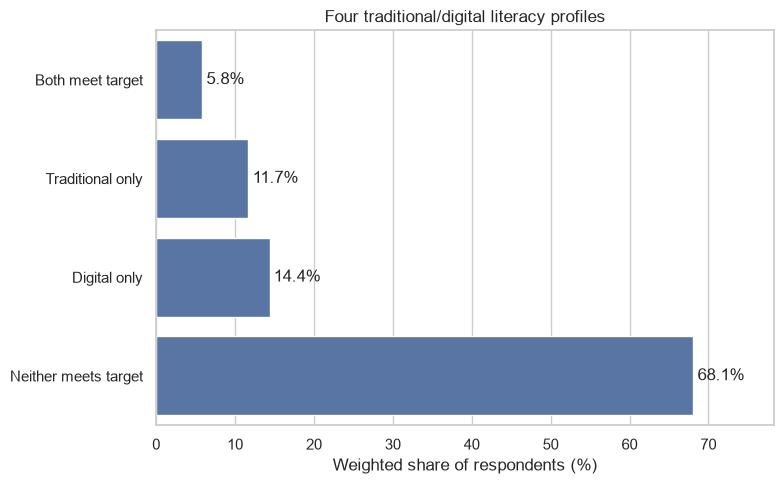

In [13]:
# 保存四类人群比例
# Save the proportions of the four population groups
profile_share.round(2).to_csv(TABLE_DIR / "literacy_profiles.csv")

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=profile_share.values,
    y=profile_share.index,
    color="#4C72B0",
)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.xlabel("Weighted share of respondents (%)")
plt.ylabel("")
plt.title("Four traditional/digital literacy profiles")
plt.xlim(0, max(profile_share.values) * 1.15)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "literacy_profiles.png", dpi=300)
plt.show()

## 8. Demographic comparison

We now compare the two scores across age, gender, education, and region. These are descriptive comparisons: they show differences between groups but do not prove that a demographic characteristic causes financial literacy.

In [14]:
# 年龄：如果受访者没有报告准确年龄，就使用其年龄段的中点
# Age: If the respondent did not report their exact age,
# use the midpoint of their age range.
age_midpoint = {1: 18.5, 2: 24.5, 3: 34.5, 4: 44.5, 5: 54.5, 6: 64.5, 7: 74.5}
analysis["age"] = analysis["qd7"].where(
    analysis["qd7"].ge(18),
    analysis["qd7_a"].map(age_midpoint),
)
analysis["age_group"] = pd.cut(
    analysis["age"],
    bins=[18, 35, 50, 65, 80],
    right=False,
    labels=["18-34", "35-49", "50-64", "65-79"],
)

# 性别：问卷编码1为男性，0为女性
# Gender: male coded as 1 and female coded as 0
analysis["gender"] = analysis["qd1"].map({1: "Men", 0: "Women"})

# 将十个教育选项合并成三个更容易比较的组
# merge 10 educational options into 3 groups easier to compare
analysis["education"] = np.select(
    [
        analysis["qd9"].le(4),
        analysis["qd9"].between(5, 6),
        analysis["qd9"].between(7, 10),
    ],
    ["Tertiary", "Upper secondary", "Lower secondary or less"],
    default="Unknown",
)

# 将五个宏观地区合并成北部、中部、南部及岛屿
# The five macro regions are merged into North, Central, South, and Islands.
analysis["region"] = np.select(
    [
        analysis["qd2"].isin([1, 2]),
        analysis["qd2"].eq(3),
        analysis["qd2"].isin([4, 5]),
    ],
    ["North", "Centre", "South and Islands"],
    default="Unknown",
)

In [15]:
# 计算每个群体的调查加权平均分
# calculate the weighted average of each group
def compare_scores(group_column, group_order):
    rows = []
    for group in group_order:
        part = analysis.loc[analysis[group_column] == group]
        rows.append(
            {
                "Group": group,
                "Traditional score": weighted_mean(part["traditional_pct"], part["wght"]),
                "Digital score": weighted_mean(part["digital_pct"], part["wght"]),
            }
        )
    return pd.DataFrame(rows).set_index("Group")

gender_scores = compare_scores("gender", ["Men", "Women"])
age_scores = compare_scores("age_group", ["18-34", "35-49", "50-64", "65-79"])
education_scores = compare_scores(
    "education",
    ["Tertiary", "Upper secondary", "Lower secondary or less"],
)
region_scores = compare_scores("region", ["North", "Centre", "South and Islands"])

# 合并并保存结果表
# Merge and store the result table
demographic_scores = pd.concat(
    {
        "Gender": gender_scores,
        "Age": age_scores,
        "Education": education_scores,
        "Region": region_scores,
    },
    names=["Characteristic", "Group"],
)
demographic_scores.round(2).to_csv(TABLE_DIR / "demographic_scores.csv")
demographic_scores.round(2)

Traditional score  Digital score
Characteristic Group                                                    
Gender         Men                                 55.510         46.950
               Women                               53.490         45.080
Age            18-34                               50.040         42.610
               35-49                               56.690         47.640
               50-64                               55.840         46.450
               65-79                               55.010         47.690
Education      Tertiary                            59.540         51.420
               Upper secondary                     54.450         45.400
               Lower secondary or less             48.030         40.640
Region         North                               55.960         47.560
               Centre                              54.920         45.840
               South and Islands                   52.260         44.020

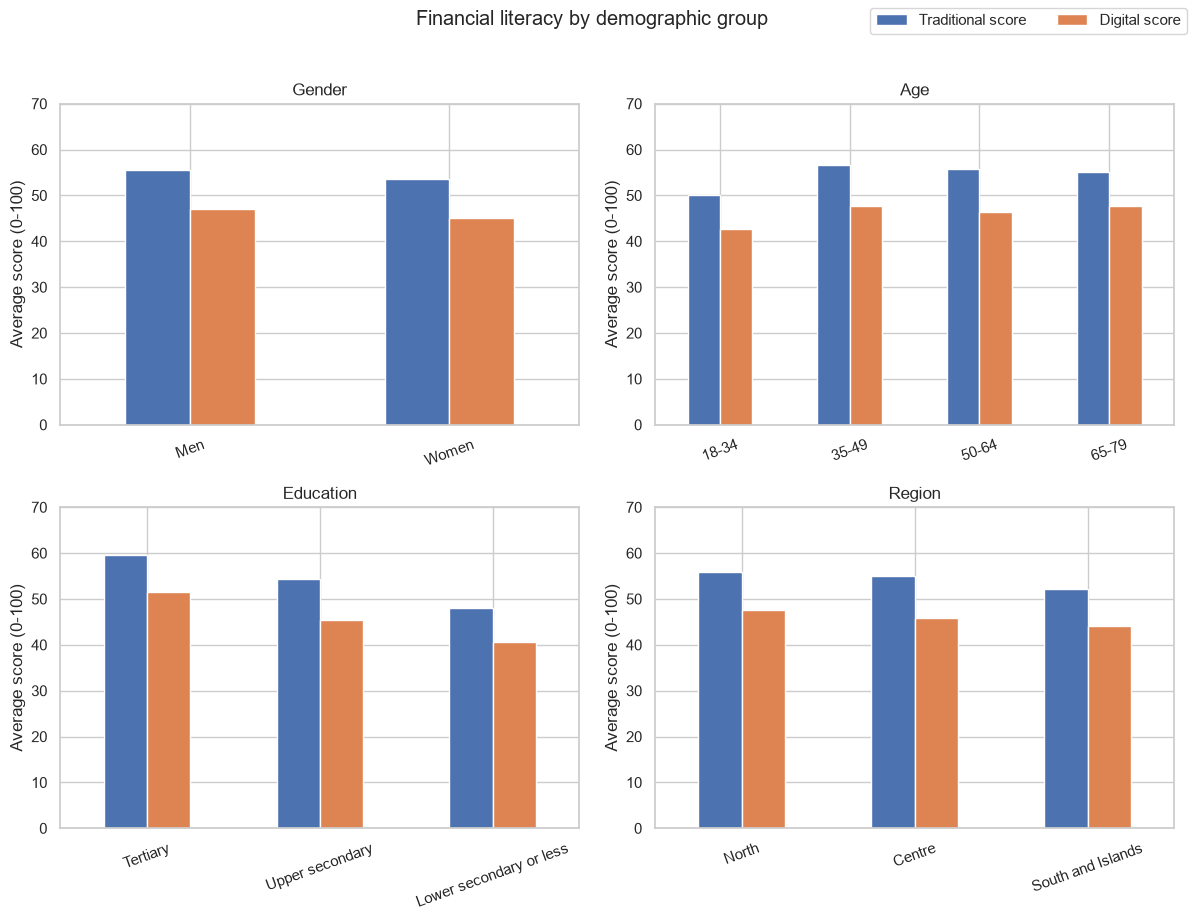

In [16]:
# 用四张简单柱状图展示人口特征差异
# Use four bar charts to illustrate differences
# in population characteristics.
score_tables = {
    "Gender": gender_scores,
    "Age": age_scores,
    "Education": education_scores,
    "Region": region_scores,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (title, table) in zip(axes.flat, score_tables.items()):
    table.plot(
        kind="bar",
        ax=ax,
        color=["#4C72B0", "#DD8452"],
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Average score (0-100)")
    ax.set_ylim(0, 70)
    ax.tick_params(axis="x", rotation=20)
    ax.legend().remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=2)
fig.suptitle("Financial literacy by demographic group", y=1.02)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "demographic_scores.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Literacy profiles by age and education

Average scores are useful, but they can hide people who are strong in only one type of literacy. We therefore compare the four profiles across age and education.

In [17]:
# 计算每个群体中四类金融素养人群的加权比例
# Calculate the weighted proportions of
# the four financial literacy groups within each group.
def profile_shares_by_group(group_column, group_order):
    rows = []
    for group in group_order:
        part = analysis.loc[analysis[group_column] == group]
        shares = (
            part.groupby("literacy_profile")["wght"]
            .sum()
            .div(part["wght"].sum())
            .mul(100)
            .reindex(profile_order, fill_value=0)
        )
        shares.name = group
        rows.append(shares)
    return pd.DataFrame(rows)

age_profiles = profile_shares_by_group(
    "age_group", ["18-34", "35-49", "50-64", "65-79"]
)
education_profiles = profile_shares_by_group(
    "education", ["Tertiary", "Upper secondary", "Lower secondary or less"]
)

age_profiles.round(2).to_csv(TABLE_DIR / "age_profiles.csv")
education_profiles.round(2).to_csv(TABLE_DIR / "education_profiles.csv")

display(age_profiles.round(2))
display(education_profiles.round(2))

literacy_profile,Both meet target,Traditional only,Digital only,Neither meets target
18-34,3.340,11.430,12.730,72.500
35-49,6.830,13.780,14.880,64.520
50-64,6.740,10.940,15.500,66.820
65-79,6.260,9.490,13.890,70.360


literacy_profile,Both meet target,Traditional only,Digital only,Neither meets target
Tertiary,9.920,16.270,17.300,56.510
Upper secondary,4.980,12.030,12.600,70.390
Lower secondary or less,2.840,4.740,15.460,76.960


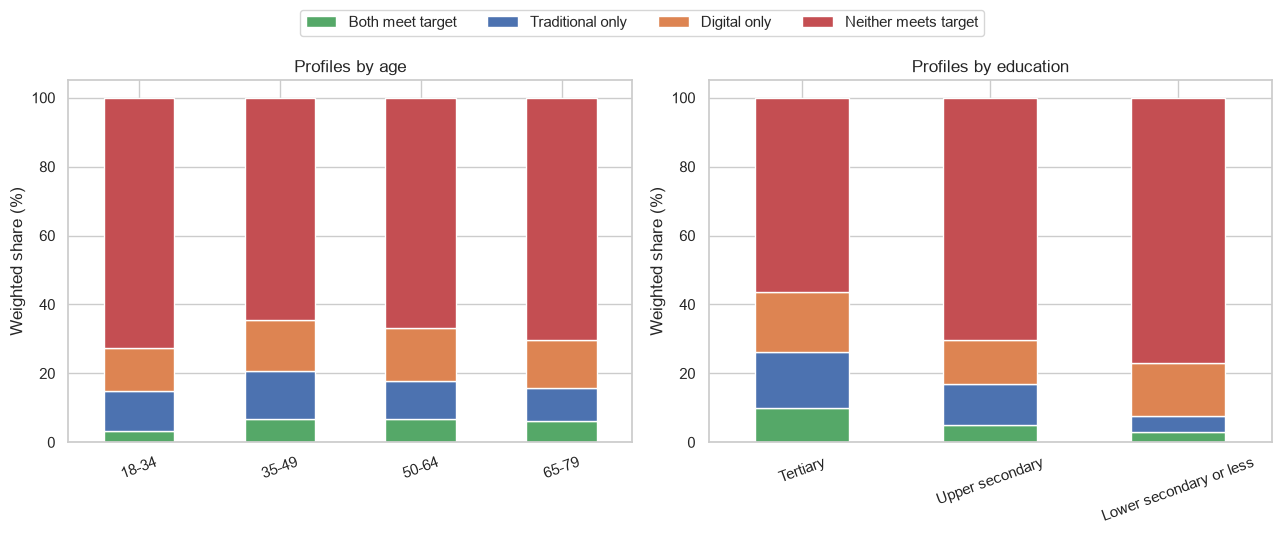

In [18]:
# 堆叠柱状图显示四类人群在年龄和教育组中的构成
# Stacked bar charts show the composition
# of the four population groups by age and education level.
profile_colors = ["#55A868", "#4C72B0", "#DD8452", "#C44E52"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

age_profiles.plot(kind="bar", stacked=True, ax=axes[0], color=profile_colors)
education_profiles.plot(kind="bar", stacked=True, ax=axes[1], color=profile_colors)

axes[0].set_title("Profiles by age")
axes[1].set_title("Profiles by education")
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Weighted share (%)")
    ax.tick_params(axis="x", rotation=20)
    ax.legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.savefig(FIGURE_DIR / "profiles_by_age_education.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Main descriptive findings

- Traditional scores are higher than digital scores in every demographic group.
- Education shows the clearest difference: respondents with tertiary education have the highest average scores, while those with lower-secondary education or less have the lowest.
- Regional differences are present but smaller than the education gap.
- The two mixed profiles (traditional only and digital only) appear in every group. This supports reporting traditional and digital literacy separately instead of replacing them with one combined score.

These results are descriptive and should not be interpreted as causal effects.

## 11. Digital financial activity

We next check whether the four literacy profiles differ in their use of digital financial services. We count how many online activities respondents used during the last 12 months and how many financial products they had obtained completely online.

In [19]:
# 七种数字金融活动：使用过（有时、经常或非常经常）记为1
# Seven types of digital financial activities:
# Used (sometimes, often, or very often) as 1
activity_columns = ["qp9_1", "qp9_3", "qp9_4", "qp9_5", "qp9_6", "qp9_7", "qp9_10"]
activity_answered = analysis[activity_columns].isin([1, 2, 3, 4]).any(axis=1)
analysis["digital_activity_count"] = (
    analysis[activity_columns].isin([2, 3, 4]).sum(axis=1).where(activity_answered)
)

# 五种完全在线办理的金融产品：办理过记为1
# Five financial products that can be processed entirely online:
# One transaction is recorded as one of the following.
online_product_columns = ["qp8_1", "qp8_2", "qp8_3", "qp8_4", "qp8_5"]
product_answered = analysis[online_product_columns].isin([0, 1]).any(axis=1)
analysis["online_product_count"] = (
    analysis[online_product_columns].eq(1).sum(axis=1).where(product_answered)
)

In [20]:
# 比较四类金融素养人群的平均数字活动数量
# Comparing the average number of digital activities
# among four types of financially literate individuals
activity_rows = []
for profile in profile_order:
    part = analysis.loc[analysis["literacy_profile"] == profile]
    activity_part = part.dropna(subset=["digital_activity_count"])
    product_part = part.dropna(subset=["online_product_count"])
    activity_rows.append(
        {
            "Profile": profile,
            "Digital activities (0-7)": weighted_mean(
                activity_part["digital_activity_count"], activity_part["wght"]
            ),
            "Online products (0-5)": weighted_mean(
                product_part["online_product_count"], product_part["wght"]
            ),
        }
    )

activity_by_profile = pd.DataFrame(activity_rows).set_index("Profile")
activity_by_profile.round(2).to_csv(TABLE_DIR / "digital_activity_by_profile.csv")
activity_by_profile.round(2)

,Digital activities (0-7),Online products (0-5)
Profile,,
Both meet target,4.230,0.860
Traditional only,4.150,0.620
Digital only,4.140,0.660
Neither meets target,3.900,0.450


## 12. Adverse financial experiences

We also examine four experiences related to scams, phishing, unauthorised card use, and unrecognised transactions during the last two years. This comparison must be interpreted carefully because people who use more digital services may also have greater exposure to these risks.

In [21]:
# 前四项是诈骗、信息泄露、盗刷和不明交易
# The first four are fraud, information leakage,
# credit card fraud, and unauthorized transactions.
risk_columns = ["qp10_1", "qp10_2", "qp10_3", "qp10_4"]
risk_answered = analysis[risk_columns].isin([0, 1]).any(axis=1)
analysis["any_adverse_experience"] = (
    analysis[risk_columns].eq(1).any(axis=1).where(risk_answered)
)

# 计算每类人中至少经历过一种问题的加权比例
# Calculate the weighted proportion
# of each group of people who have experienced at least one problem.
risk_rows = []
for profile in profile_order:
    part = analysis.loc[
        (analysis["literacy_profile"] == profile)
        & analysis["any_adverse_experience"].notna()
    ]
    risk_rows.append(
        {
            "Profile": profile,
            "Experienced at least one issue (%)": weighted_mean(
                part["any_adverse_experience"], part["wght"]
            ) * 100,
        }
    )

risk_by_profile = pd.DataFrame(risk_rows).set_index("Profile")
risk_by_profile.round(2).to_csv(TABLE_DIR / "adverse_experience_by_profile.csv")
risk_by_profile.round(2)

,Experienced at least one issue (%)
Profile,
Both meet target,13.340
Traditional only,15.480
Digital only,16.130
Neither meets target,15.240


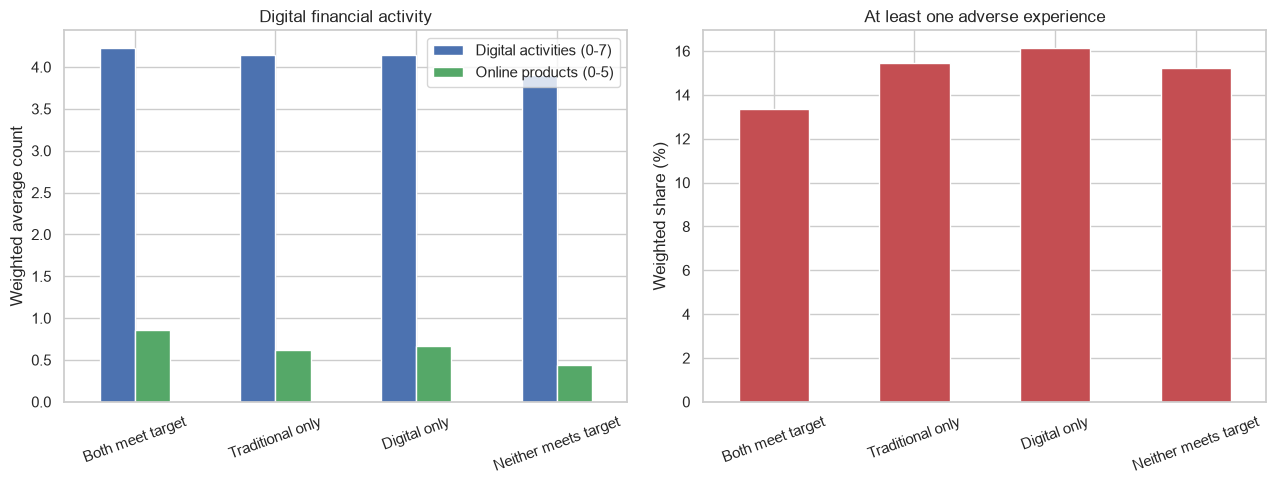

In [22]:
# 左图显示数字金融参与，右图显示至少一次负面经历
# The left chart shows participation in digital finance,
# the right chart shows at least one negative experience.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

activity_by_profile.plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#55A868"]
)
axes[0].set_title("Digital financial activity")
axes[0].set_ylabel("Weighted average count")
axes[0].set_xlabel("")

risk_by_profile.plot(
    kind="bar", ax=axes[1], color="#C44E52", legend=False
)
axes[1].set_title("At least one adverse experience")
axes[1].set_ylabel("Weighted share (%)")
axes[1].set_xlabel("")

for ax in axes:
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "digital_activity_and_risk.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Interpretation of this step

- Respondents who meet both targets use an average of 4.23 digital activities and have obtained 0.86 products online. Those who meet neither target have the lowest averages: 3.90 activities and 0.45 products.
- The two mixed profiles have almost the same average number of digital activities (4.15 for traditional only and 4.14 for digital only). This suggests that actual service use is not explained by only one literacy score.
- The percentage reporting at least one adverse experience ranges from 13.34% to 16.13%, without a simple pattern in which higher literacy always means fewer problems.

The risk result is descriptive rather than causal. People who use more digital services may have more opportunities to encounter a problem, so a higher percentage does not automatically mean that they are less careful.